# Skew-T/Log-P Diagrams by Lightning/OT Category (Land vs Ocean, Warm Season)

Purpose: Produce a 2x3 grid of Skew-T/log-P diagrams comparing environmental and parcel
temperature/dew point profiles across lightning/OT co-occurrence categories (OT only,
OT+LS, LS only), split by land and ocean, using virtual temperature to correctly represent
buoyancy (CAPE/CIN) in the presence of moisture.

Input:
- Weighted-mean vertical profile CSVs (from 11_weighted_mean_profiles_for_skewT.ipynb):
  BARRA_data_skew_T/mean_data/MUCAPE_0/with_screen_level_MUCAPE_0_mean_data_<group>_<surface>.csv
- Weighted-average initial parcel parameter CSVs (from the same notebook):
  BARRA_data_skew_T/warm_season_initial_parameters/with_weighted_avg_<group>_<surface>.csv
- Requires local `atmos.thermo` and `atmos.moisture` modules for virtual temperature and
  specific humidity calculations

Processing:
1. For each of the 6 category/surface combinations, load the mean environmental profile
   (temperature, dew point by pressure level) and the mean initial parcel parameters
   (pressure, temperature, dew point).
2. Compute environmental specific humidity from dew point, and lift a parcel from its
   initial level to derive the parcel's temperature profile and LCL.
3. Compute virtual temperature for both the environment and the lifted parcel, to
   correctly represent moist buoyancy.
4. Plot a Skew-T diagram per panel: environmental T/Td, parcel T profile, virtual
   temperature curves (environment and parcel), LCL marker, and shaded CAPE/CIN
   (computed from virtual temperature, not raw temperature).
5. Arrange panels in a 2 (land/ocean) x 3 (OT only / OT+LS / LS only) grid, with shared
   axis limits, panel labels, and a single shared legend.

Output:
- Figure saved to:
  /g/data/if69/tp4064/Project_1/Plots/warm_season/
  corrected_screen_parcel_included_virtual_temp_warm_skewTlogP.png

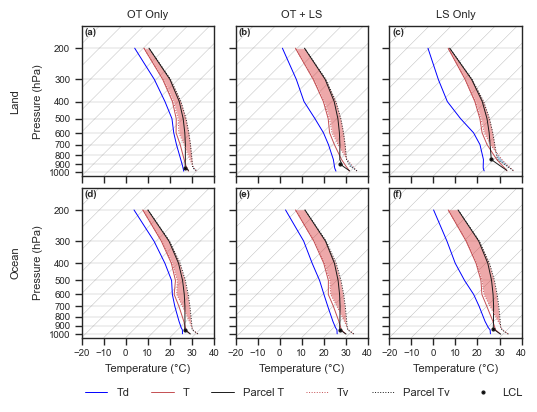

In [4]:
#with virtual temp

import sys

sys.path.append('/g/data/if69/tp4064/old_before_new_data_merge/BARRA_combine_data')
from atmos import thermo
from atmos import moisture
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from metpy.plots import SkewT
import metpy.calc as mpcalc
from metpy.units import units

import seaborn as sns
from pathlib import Path

# 1. Define your 3 groups (columns)
groups = ['ot_only', 'ls_ot', 'ls_only']
# 2. Define your 2 categories (rows)
surface_types = ['land', 'ocean']
titles = ['OT Only', 'OT + LS', 'LS Only']
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

data_dir = Path("/g/data/if69/tp4064/Project_1/categorical_position/BARRA_data_skew_T/")

sns.set_theme(style="ticks", context="paper") 
fig = plt.figure(figsize=(5, 3.5))
plot_idx = 1 # Counter for subplot position (1 to 6)
font_size = 7
line_width = 0.7



for row_type in surface_types:
    for col_group in groups:
        # Load your specific file for this group
        # Adjust path logic if land/ocean are in separate files or the same file
       
        path = data_dir/'mean_data'/'MUCAPE_0'/f'with_screen_level_MUCAPE_0_mean_data_{col_group}_{row_type}.csv'
        mean_data = pd.read_csv(path)

        initial_path = data_dir/'warm_season_initial_parameters'/f'with_weighted_avg_{col_group}_{row_type}.csv'

        initial_data = pd.read_csv(initial_path)

        parcel_pres = initial_data.loc[(initial_data['year'] == 'total', 'MULPLpres_mean')].values[0]
        parcel_temp = initial_data.loc[(initial_data['year'] == 'total', 'MULPLtemp_mean')].values[0]
        parcel_dew = initial_data.loc[(initial_data['year'] == 'total', 'MULPLdew_mean')].values[0]

        parcel_pressure_levels = mean_data.pressure.values.copy()

        T = mean_data[f'{col_group}_{row_type}_temperature']+273.15
        
        q = moisture.specific_humidity_from_dewpoint_temperature(mean_data['pressure']*100,mean_data[f'{col_group}_{row_type}_dew']+273.15) # environmental specific humidity

        if ((parcel_pressure_levels[0] < parcel_pres) or (parcel_pressure_levels[0] > parcel_pres)): 
            
            parcel_pressure_levels[0] = parcel_pres


        # note : for parcel pressur elevels, when parcel pressure is greater than 1000hpa, I could had inserted pressure 1000hpa
        # but it was creating alot problem while shading the CAPE, so it replaced it everywhere, wether greater than or less than.

        
        # Select data based on row (assuming 'land' and 'ocean' are columns in your CSV)
        # e.g., 'ot_only_land_temperature_nt'
        p_mean = (mean_data.pressure.values) * units.hPa
        t_col = f'{col_group}_{row_type}_temperature'
        d_col = f'{col_group}_{row_type}_dew'
        
        t_mean = mean_data[t_col].values * units.degC
        dew_mean = mean_data[d_col].values * units.degC

        parcel_spec = moisture.specific_humidity_from_dewpoint_temperature(parcel_pres*100,parcel_dew+273.15)
        parcel_pressure_levels = parcel_pressure_levels* units.hPa
        parcel_pres = parcel_pres* units.hPa
        parcel_temp = parcel_temp* units.degC
        parcel_dew = parcel_dew* units.degC

        # Calculate and plot Parcel / LCL
        lcl_p, lcl_t = mpcalc.lcl(parcel_pres, parcel_temp, parcel_dew)
        Tp = mpcalc.parcel_profile(parcel_pressure_levels, parcel_temp, parcel_dew)
        lcl_prof = Tp.to('degC')
        


        qp = np.where(parcel_pressure_levels.magnitude*100 < lcl_p.magnitude*100, thermo.saturation_specific_humidity(parcel_pressure_levels.magnitude*100, Tp.magnitude), parcel_spec)

        Tv = np.asarray(thermo.virtual_temperature(T, q)-273.15)*units.degC    # environmental virtual temperature
        Tvp = np.asarray(thermo.virtual_temperature(Tp.magnitude,qp)-273.15)*units.degC # parcel virtual temperature

        
        # --- Initialize SkewT for this specific grid cell ---
        skewt = SkewT(fig=fig, subplot=(2, 3, plot_idx),rotation=45)

        skewt.ax.grid(True, which='both', color='grey', linestyle='-', linewidth=line_width-1, alpha=0.6)
        
        # Plot Temp and Dewpoint
        skewt.plot(p_mean, dew_mean, 'blue',linewidth = line_width,label='Td' )
        skewt.plot(p_mean, t_mean, 'r',linewidth = line_width, label='T' )
        skewt.plot(parcel_pressure_levels, lcl_prof, 'k', linestyle='-',linewidth = line_width,label='Parcel T')
        
    

        skewt.plot(p_mean, Tv, 'r',linestyle=':',linewidth = line_width, label='Tv' )
        skewt.plot(parcel_pressure_levels, Tvp, 'k',linestyle=':',linewidth = line_width,label='Parcel Tv' )

        
        
        skewt.plot(lcl_p, lcl_t, 'ko', markerfacecolor='black', markersize = font_size-5, label='LCL')
        # skewt.shade_cape(p_mean, t_mean, lcl_prof)
        # skewt.shade_cin(p_mean, t_mean, lcl_prof)
        skewt.shade_cape(p_mean, Tv, Tvp)
        skewt.shade_cin(p_mean, Tv, Tvp)
        

        # 3. Add Panel Label (e.g., (a), (b)...)
        # transform=skewt.ax.transAxes places it relative to the subplot box (0,0 is bottom left)
        skewt.ax.text(0.02, 0.99, panel_labels[plot_idx-1], 
                      transform=skewt.ax.transAxes, 
                      fontsize=font_size ,fontweight = 'bold', va='top')

        skewt.ax.tick_params(axis='x', labelsize=font_size)
        skewt.ax.tick_params(axis='y', labelsize=font_size)


        # Formatting individual subplot
                # --- Add Titles ONLY to the first row (indices 0, 1, 2) ---
        if plot_idx <= 3:
            skewt.ax.set_title(titles[plot_idx-1], fontsize=font_size+1)
        # skewt.ax.set_title(f"{col_group.upper()} - {row_type.capitalize()}", fontsize=14)
        skewt.ax.set_xlim(-20, 40)
        skewt.ax.set_ylim(1050, 150)


        # 2. Add Row Labels (Land/Ocean) to the first column
        if (plot_idx == 1) or (plot_idx == 4):
            # This adds a bold label to the left of the Y-axis
            skewt.ax.set_ylabel(f"{row_type.capitalize()}\n\nPressure (hPa)", 
                                fontsize=font_size+1 )
        elif (plot_idx-1) % 3 != 0:
            # Clear the label entirely for middle and right columns
            skewt.ax.set_ylabel("")
            # Remove Y-axis labels for middle/right columns to save space
            skewt.ax.set_yticklabels([])
        
        if plot_idx <= 3: # Only label X-axis on bottom row
            skewt.ax.set_xlabel("")
            skewt.ax.set_xticklabels([])

        else:

            skewt.ax.set_xlabel('Temperature (°C)', fontsize=font_size+1 )
            
        # if plot_idx % 3 == 1: # Only label Y-axis on left column
        #     skewt.ax.set_ylabel('Pressure (hPa)')

        if plot_idx == 1:
        # Store handles and labels from the first axes for the global legend
            handles, labels = skewt.ax.get_legend_handles_labels()
            

        plot_idx += 1

fig.legend(handles, labels, loc='lower center', ncol = 6,fontsize=font_size+1, bbox_to_anchor=(0.55,-0.1), frameon=False)

        

plt.subplots_adjust(
    left=0.1,    # Room for Land/Ocean text
    right=0.99,  # Edge of figure
    top=0.99,    # Room for 'OT Only' titles
    bottom=0.1, # Room for 'Temperature' label
    wspace=0.12, # NEGATIVE value pulls columns together
    hspace=0.08   # Space between Land and Ocean rows
)


plt.savefig("/g/data/if69/tp4064/Project_1/Plots/warm_season/corrected_screen_parcel_included_virtual_temp_warm_skewTlogP.png", dpi = 400,bbox_inches='tight')
plt.show()